# 02 - Metrics Anomaly Detection

Build a leakage-aware statistical detection pipeline for CPU, memory, and network telemetry. Application and MongoDB metrics are kept separate, and canonical series are selected before aggregation to avoid double counting.

## 1. Configuration and scenario setup

In [58]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

SCENARIO_ID = "ts-auth-mongo_4.4.15_2022-07-13"

# Hỗ trợ chạy notebook từ thư mục notebooks/ hoặc project root
PROJECT_ROOT = Path("..") if Path("../data/raw").exists() else Path(".")
SCENARIO_DIR = PROJECT_ROOT / "data" / "raw" / SCENARIO_ID

RESAMPLE_INTERVAL = "30s"
MAX_COUNTER_GAP_SECONDS = 90

CPU_METRIC = "container_cpu_usage_seconds_total"
MEMORY_METRIC = "container_memory_working_set_bytes"
NETWORK_METRIC = "container_network_transmit_packets_total"

TARGET_METRICS = {
    CPU_METRIC,
    MEMORY_METRIC,
    NETWORK_METRIC,
}

print("Scenario:", SCENARIO_DIR.resolve())
assert SCENARIO_DIR.exists(), f"Scenario không tồn tại: {SCENARIO_DIR}"

Scenario: E:\AIO\Project\aiops-trainticket-pipeline\data\raw\ts-auth-mongo_4.4.15_2022-07-13


## 2. Load canonical metric series

Select container-level CPU and memory series, pod-level network series, and classify them as application or MongoDB telemetry.

#### What does canonical series mean?

A Prometheus metric file contains many labeled time series, including multiple views of the same Kubernetes workload. For example, CPU or memory may be reported for the application container, the whole pod cgroup, and the infrastructure sandbox. Adding all of those views would count part of the same resource more than once. A **canonical series** is the single, intentionally selected view that this notebook treats as the source of truth for a metric.

The selection rule depends on the metric:

- **CPU and memory:** use the actual workload container (`ts-auth-service` or `ts-auth-mongo`) and exclude pod-level and sandbox series.
- **Network:** use `container=POD` because containers in a Kubernetes pod share the pod network namespace; identify the owner from the `pod` label.
- Keep the authentication application (`application`) and its database (`mongo`) as separate entities.

This section produces two different tables:

- `series_inventory`: one row per selected time series, used to inspect labels and sample counts. It does not contain individual metric values.
- `raw_metrics`: one row per timestamped sample, including the raw `value` used by later transformation and detection steps.

At this stage the six logical groups (three metrics × two entities) are appended vertically in long format. They have not been merged into six value columns.

In [59]:
def classify_series(labels):
    """
    Chọn đúng entity và đúng cấp metric để tránh double counting.
    """
    metric_name = labels.get("__name__")
    pod = str(labels.get("pod") or "")
    container = labels.get("container")

    if metric_name not in TARGET_METRICS:
        return None

    # CPU và memory: lấy container-level
    if metric_name in {CPU_METRIC, MEMORY_METRIC}:
        if container == "ts-auth-service":
            return "application"

        if container == "ts-auth-mongo":
            return "mongo"

        return None

    # Network: lấy pod network namespace
    if metric_name == NETWORK_METRIC and container == "POD":
        if pod.startswith("ts-auth-service-"):
            return "application"

        if pod.startswith("ts-auth-mongo-"):
            return "mongo"

    return None


metric_files = sorted(
    p
    for folder in SCENARIO_DIR.glob("Monitoring_*")
    for p in folder.glob("*.json")
)

rows = []
series_inventory = []

for file in metric_files:
    document = json.loads(file.read_text(encoding="utf-8"))

    for index, series in enumerate(document["data"]["result"]):
        labels = series.get("metric", {})
        entity = classify_series(labels)

        if entity is None:
            continue

        metric_name = labels["__name__"]
        series_id = f"{file.name}:{index}"

        values = series.get("values", [])

        series_inventory.append({
            "series_id": series_id,
            "entity": entity,
            "metric_name": metric_name,
            "pod": labels.get("pod"),
            "container": labels.get("container"),
            "image": labels.get("image"),
            "instance": labels.get("instance"),
            "sample_count": len(values),
        })

        for timestamp, value in values:
            rows.append({
                "timestamp": pd.to_datetime(
                    float(timestamp),
                    unit="s",
                    utc=True,
                ),
                "value": pd.to_numeric(value, errors="coerce"),
                "series_id": series_id,
                "entity": entity,
                "metric_name": metric_name,
                "pod": labels.get("pod"),
                "container": labels.get("container"),
                "image": labels.get("image"),
                "instance": labels.get("instance"),
            })

raw_metrics = (
    pd.DataFrame(rows)
    .sort_values(["series_id", "timestamp"])
    .reset_index(drop=True)
)

series_inventory = pd.DataFrame(series_inventory)

print("Selected samples:", len(raw_metrics))
display(series_inventory)

Selected samples: 751


,series_id,entity,metric_name,pod,container,image,instance,sample_count
0,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,53
1,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-df88ffc66-fhd5t,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.22:10250,1
2,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6f9dfd688d-wgl8s,ts-auth-mongo,docker.io/library/mongo:5.0.9,10.252.1.23:10250,65
3,ts-auth-service_3_Mongo_4.4.15.json_container_...,application,container_cpu_usage_seconds_total,ts-auth-service-96d95d474-bdfpt,ts-auth-service,docker.io/codewisdom/ts-auth-service-with-jaeg...,10.252.1.21:10250,53
4,ts-auth-service_3_Mongo_4.4.15.json_container_...,application,container_cpu_usage_seconds_total,ts-auth-service-b794cb6bb-cpx5q,ts-auth-service,docker.io/codewisdom/ts-auth-service-with-jaeg...,10.252.1.23:10250,77
5,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_memory_working_set_bytes,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,54
6,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_memory_working_set_bytes,ts-auth-mongo-df88ffc66-fhd5t,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.22:10250,2
7,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_memory_working_set_bytes,ts-auth-mongo-6f9dfd688d-wgl8s,ts-auth-mongo,docker.io/library/mongo:5.0.9,10.252.1.23:10250,65
8,ts-auth-service_3_Mongo_4.4.15.json_container_...,application,container_memory_working_set_bytes,ts-auth-service-96d95d474-bdfpt,ts-auth-service,docker.io/codewisdom/ts-auth-service-with-jaeg...,10.252.1.21:10250,55
9,ts-auth-service_3_Mongo_4.4.15.json_container_...,application,container_memory_working_set_bytes,ts-auth-service-b794cb6bb-cpx5q,ts-auth-service,docker.io/codewisdom/ts-auth-service-with-jaeg...,10.252.1.23:10250,77


## 3. Validate series selection

Verify that container-level and pod-level resource views are not mixed accidentally.

In [60]:
selection_summary = (
    series_inventory
    .groupby(["entity", "metric_name"], dropna=False)
    .agg(
        series_count=("series_id", "nunique"),
        pod_count=("pod", "nunique"),
        containers=("container", lambda x: sorted(x.dropna().unique())),
        sample_count=("sample_count", "sum"),
    )
    .reset_index()
)

display(selection_summary)

cpu_memory = series_inventory[
    series_inventory["metric_name"].isin({
        CPU_METRIC,
        MEMORY_METRIC,
    })
]

network = series_inventory[
    series_inventory["metric_name"].eq(NETWORK_METRIC)
]

# CPU/memory không được chứa pod-level hoặc sandbox
assert not cpu_memory["container"].isin(["POD"]).any()
assert cpu_memory["container"].notna().all()

# Network phải lấy ở pod network namespace
assert network["container"].eq("POD").all()

# Mỗi series chỉ thuộc một entity
assert (
    series_inventory
    .groupby("series_id")["entity"]
    .nunique()
    .max()
    == 1
)

print("Canonical-series validation passed.")

,entity,metric_name,series_count,pod_count,containers,sample_count
0,application,container_cpu_usage_seconds_total,2,2,[ts-auth-service],130
1,application,container_memory_working_set_bytes,2,2,[ts-auth-service],132
2,application,container_network_transmit_packets_total,2,2,[POD],130
3,mongo,container_cpu_usage_seconds_total,3,3,[ts-auth-mongo],119
4,mongo,container_memory_working_set_bytes,3,3,[ts-auth-mongo],121
5,mongo,container_network_transmit_packets_total,3,3,[POD],119


Canonical-series validation passed.


## 4. Transform counters and gauges

Convert CPU and network counters to per-second rates and memory bytes to MiB, independently for each time series.

In [61]:
def transform_series(group):
    # Sắp xếp dữ liệu theo thời gian để diff() được tính đúng thứ tự
    group = group.sort_values("timestamp").copy()

    # Mỗi group tương ứng một series nên chỉ có một loại metric
    metric_name = group["metric_name"].iloc[0]

    # Khoảng thời gian giữa mẫu hiện tại và mẫu trước, đơn vị giây
    group["elapsed_seconds"] = (
        group["timestamp"]
        .diff()
        .dt.total_seconds()
    )

    # Mức thay đổi của giá trị so với mẫu trước
    # Hữu ích với metric dạng counter như CPU và network
    group["counter_delta"] = group["value"].diff()

    # Khởi tạo các cờ kiểm tra chất lượng dữ liệu
    group["counter_reset"] = False
    group["invalid_gap"] = False

    # CPU và network là counter tích lũy nên cần chuyển thành tốc độ
    if metric_name in {CPU_METRIC, NETWORK_METRIC}:

        # Counter giảm thường có nghĩa container/process đã restart
        group["counter_reset"] = group["counter_delta"].lt(0)

        # Khoảng lấy mẫu không hợp lệ nếu:
        # - Bằng hoặc nhỏ hơn 0 giây
        # - Lớn hơn ngưỡng cho phép, ở đây là 90 giây
        group["invalid_gap"] = (
            group["elapsed_seconds"].le(0)
            | group["elapsed_seconds"].gt(MAX_COUNTER_GAP_SECONDS)
        )

        # Chuyển counter tích lũy thành tốc độ trên mỗi giây
        # CPU: CPU-seconds / second = số CPU core sử dụng
        # Network: packets / second
        group["signal_value"] = (
            group["counter_delta"]
            / group["elapsed_seconds"]
        )

        # Xác định những mẫu không đủ tin cậy để phân tích
        invalid = (
            group["counter_reset"]                 # Counter vừa bị reset
            | group["invalid_gap"]                 # Khoảng thời gian không hợp lệ
            | group["elapsed_seconds"].isna()      # Mẫu đầu tiên không có mẫu trước
        )

        # Đánh dấu giá trị không hợp lệ bằng NaN
        group.loc[invalid, "signal_value"] = np.nan

        # Gán đơn vị tương ứng với từng loại metric
        group["unit"] = (
            "cpu_cores"
            if metric_name == CPU_METRIC
            else "packets_per_second"
        )

    # Memory là gauge: giá trị tại thời điểm đo, không cần tính diff()
    elif metric_name == MEMORY_METRIC:

        # Chuyển đơn vị từ byte sang MiB
        group["signal_value"] = group["value"] / (1024 ** 2)
        group["unit"] = "MiB"

    # Trả về series đã được bổ sung các trường xử lý
    return group


# Danh sách chứa kết quả biến đổi của từng time series
transformed_groups = []

# Tách dữ liệu theo series_id để không tính diff() giữa hai series khác nhau
for _, group in raw_metrics.groupby("series_id", sort=False):
    transformed_groups.append(transform_series(group))

# Ghép tất cả series đã xử lý thành một DataFrame
transformed = (
    pd.concat(transformed_groups, ignore_index=True)
    # Sắp xếp lại để dữ liệu dễ đọc và xử lý ở các bước sau
    .sort_values(["series_id", "timestamp"])
)


# Tổng hợp thông tin chất lượng dữ liệu theo thành phần và loại metric
quality_summary = (
    transformed
    .groupby(["entity", "metric_name"])
    .agg(
        # Tổng số dòng, bao gồm cả signal_value bị NaN
        rows=("signal_value", "size"),

        # Số signal_value hợp lệ; count() tự bỏ qua NaN
        valid_values=("signal_value", "count"),

        # Tổng số lần phát hiện counter bị reset
        # True được tính là 1, False được tính là 0
        counter_resets=("counter_reset", "sum"),

        # Tổng số khoảng thời gian lấy mẫu không hợp lệ
        invalid_gaps=("invalid_gap", "sum"),
    )
    # Đưa entity và metric_name từ index trở lại thành cột
    .reset_index()
)

# Hiển thị bảng tổng hợp chất lượng dữ liệu
display(quality_summary)

# Hiển thị 5 dòng đầu tiên của dữ liệu sau biến đổi
display(transformed.head())

,entity,metric_name,rows,valid_values,counter_resets,invalid_gaps
0,application,container_cpu_usage_seconds_total,130,128,0,0
1,application,container_memory_working_set_bytes,132,132,0,0
2,application,container_network_transmit_packets_total,130,128,0,0
3,mongo,container_cpu_usage_seconds_total,119,116,0,0
4,mongo,container_memory_working_set_bytes,121,121,0,0
5,mongo,container_network_transmit_packets_total,119,116,0,0


,timestamp,value,series_id,entity,metric_name,pod,container,image,instance,elapsed_seconds,counter_delta,counter_reset,invalid_gap,signal_value,unit
0,2022-07-13 11:26:36.983999968+00:00,2.003523,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,NaN,NaN,False,False,NaN,cpu_cores
1,2022-07-13 11:27:06.983999968+00:00,2.165104,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,30.0,0.161581,False,False,0.005386,cpu_cores
2,2022-07-13 11:27:36.983999968+00:00,2.357967,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,30.0,0.192863,False,False,0.006429,cpu_cores
3,2022-07-13 11:28:06.983999968+00:00,2.532741,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,30.0,0.174774,False,False,0.005826,cpu_cores
4,2022-07-13 11:28:36.983999968+00:00,2.790774,ts-auth-service_3_Mongo_4.4.15.json_container_...,mongo,container_cpu_usage_seconds_total,ts-auth-mongo-6765bf594-fsf44,ts-auth-mongo,docker.io/library/mongo:4.4.15,10.252.1.23:10250,30.0,0.258032,False,False,0.008601,cpu_cores


## 5. Resample and aggregate by entity

Align individual series to 30-second windows before creating service-level sum, mean, median, maximum, and active-pod features.

In [62]:
resampled_groups = []

for series_id, group in transformed.groupby("series_id"):
    group = group.sort_values("timestamp")
    valid = group.set_index("timestamp")["signal_value"]

    sampled = (
        valid
        .resample(RESAMPLE_INTERVAL)
        .mean()
        .dropna()
        .rename("signal_value")
        .reset_index()
    )

    sampled["series_id"] = series_id
    sampled["entity"] = group["entity"].iloc[0]
    sampled["metric_name"] = group["metric_name"].iloc[0]
    sampled["pod"] = group["pod"].iloc[0]
    sampled["unit"] = group["unit"].iloc[0]

    resampled_groups.append(sampled)

per_series = (
    pd.concat(resampled_groups, ignore_index=True)
    .sort_values(["series_id", "timestamp"])
)

metric_features = (
    per_series
    .groupby(
        ["timestamp", "entity", "metric_name", "unit"],
        as_index=False,
    )
    .agg(
        value_sum=("signal_value", "sum"),
        value_mean=("signal_value", "mean"),
        value_median=("signal_value", "median"),
        value_max=("signal_value", "max"),
        active_pod_count=("pod", "nunique"),
        observed_series_count=("series_id", "nunique"),
    )
    .sort_values(["entity", "metric_name", "timestamp"])
    .reset_index(drop=True)
)

display(metric_features.head(20))

,timestamp,entity,metric_name,unit,value_sum,value_mean,value_median,value_max,active_pod_count,observed_series_count
0,2022-07-13 10:53:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.003518,0.003518,0.003518,0.003518,1,1
1,2022-07-13 10:54:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.001125,0.001125,0.001125,0.001125,1,1
2,2022-07-13 10:54:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.001367,0.001367,0.001367,0.001367,1,1
3,2022-07-13 10:55:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.000731,0.000731,0.000731,0.000731,1,1
4,2022-07-13 10:55:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.001809,0.001809,0.001809,0.001809,1,1
5,2022-07-13 10:56:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.000992,0.000992,0.000992,0.000992,1,1
6,2022-07-13 10:56:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.002375,0.002375,0.002375,0.002375,1,1
7,2022-07-13 10:57:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.002649,0.002649,0.002649,0.002649,1,1
8,2022-07-13 10:57:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.001159,0.001159,0.001159,0.001159,1,1
9,2022-07-13 10:58:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,0.001324,0.001324,0.001324,0.001324,1,1


## 6. Inspect the normalized metric timelines

Compare total resource usage with average usage per active pod before applying a detector.
- total: rely on number of pods
- mean: per pod

-> so if total and mean linear increase, because number of pods increase and total it more large

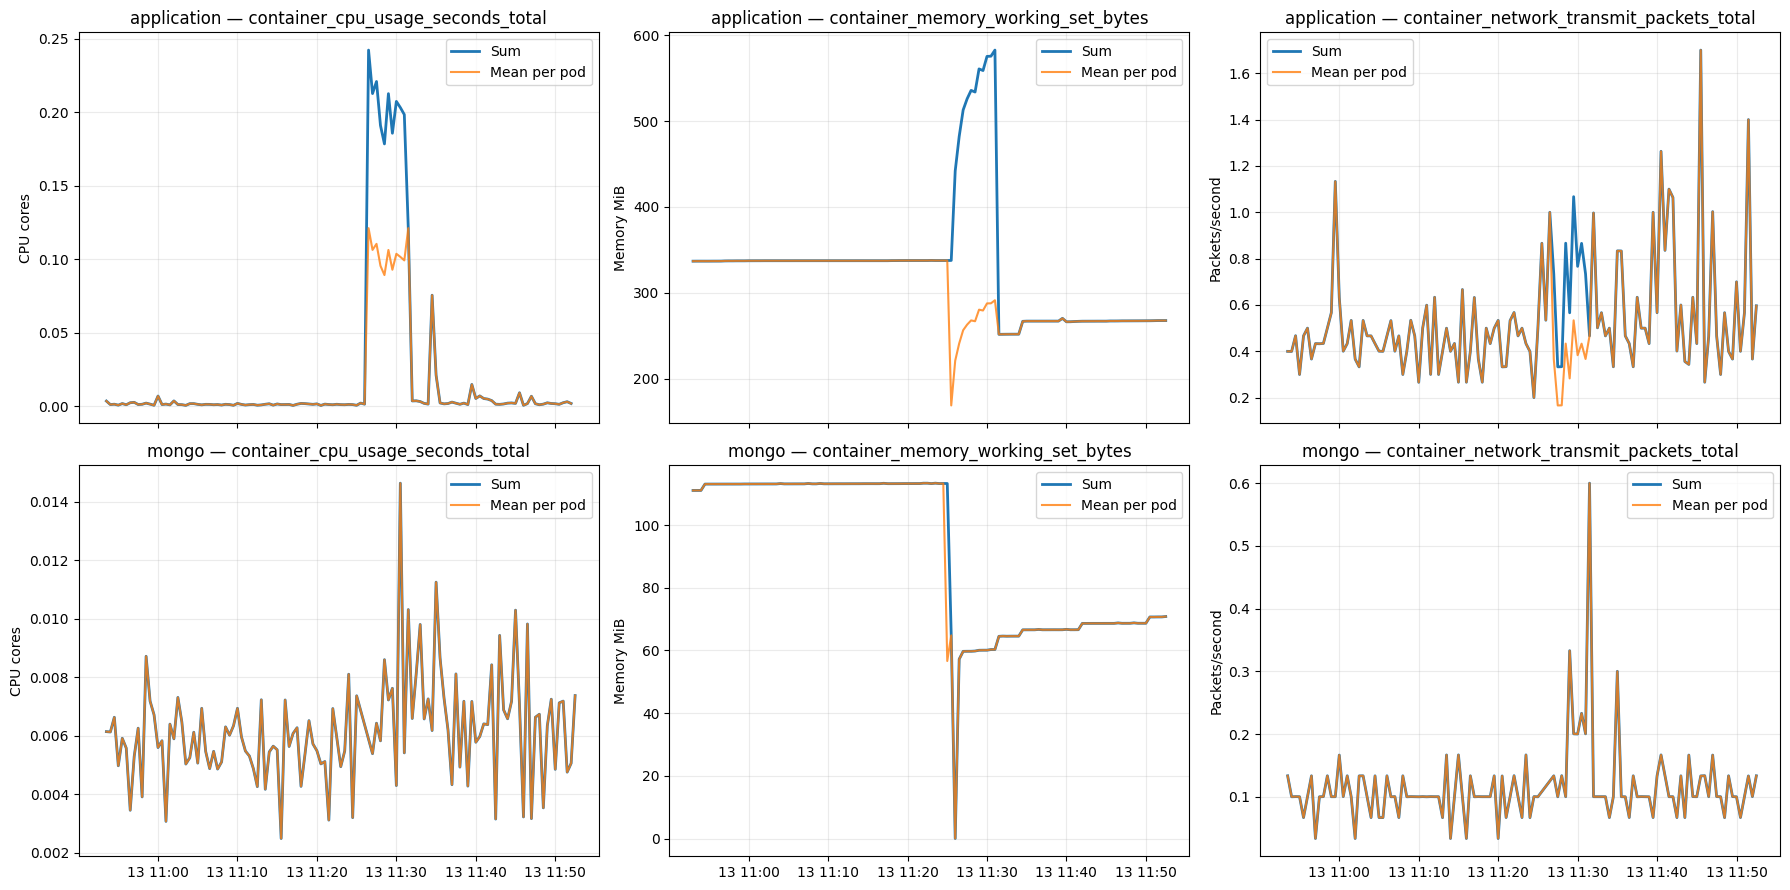

In [63]:
metric_labels = {
    CPU_METRIC: "CPU cores",
    MEMORY_METRIC: "Memory MiB",
    NETWORK_METRIC: "Packets/second",
}

entities = ["application", "mongo"]
metric_order = [CPU_METRIC, MEMORY_METRIC, NETWORK_METRIC]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 9),
    sharex=True,
)

for row_index, entity in enumerate(entities):
    for column_index, metric_name in enumerate(metric_order):
        ax = axes[row_index, column_index]

        data = metric_features[
            metric_features["entity"].eq(entity)
            & metric_features["metric_name"].eq(metric_name)
        ]

        ax.plot(
            data["timestamp"],
            data["value_sum"],
            label="Sum",
            linewidth=2,
        )

        ax.plot(
            data["timestamp"],
            data["value_mean"],
            label="Mean per pod",
            alpha=0.8,
        )

        ax.set_title(f"{entity} — {metric_name}")
        ax.set_ylabel(metric_labels[metric_name])
        ax.grid(alpha=0.25)
        ax.legend()

plt.tight_layout()
plt.show()

## 7. Prepare detection features

Convert aggregate columns into a long-form table so every entity, metric, and feature can be scored independently.

In [64]:
FEATURES_TO_SCORE = [
    "value_sum",
    "value_mean",
    "value_max",
]

feature_long = metric_features.melt(
    id_vars=[
        "timestamp",
        "entity",
        "metric_name",
        "unit",
        "active_pod_count",
        "observed_series_count",
    ],
    value_vars=FEATURES_TO_SCORE,
    var_name="feature_name",
    value_name="observed_value",
)

feature_long = feature_long.sort_values([
    "entity",
    "metric_name",
    "feature_name",
    "timestamp",
])

display(feature_long.head())

,timestamp,entity,metric_name,unit,active_pod_count,observed_series_count,feature_name,observed_value
1418,2022-07-13 10:53:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.003518
1419,2022-07-13 10:54:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.001125
1420,2022-07-13 10:54:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.001367
1421,2022-07-13 10:55:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.000731
1422,2022-07-13 10:55:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.001809


## 8. Detect anomalies with Rolling Median and MAD

Build each baseline from prior observations only and require persistent threshold violations before emitting an anomaly.

In [65]:
ROLLING_WINDOW = 20
MIN_HISTORY = 10
SCORE_THRESHOLD = 4.0

PERSISTENCE_WINDOW = 3
MIN_ANOMALOUS_POINTS = 1


def rolling_mad_detector(group):
    group = group.sort_values("timestamp").copy()

    observed = group["observed_value"].astype(float)

    # shift(1): baseline chỉ sử dụng dữ liệu quá khứ
    history = observed.shift(1)

    rolling = history.rolling(
        window=ROLLING_WINDOW,
        min_periods=MIN_HISTORY,
    )

    expected = rolling.median()

    mad = rolling.apply(
        lambda values: np.median(
            np.abs(values - np.median(values))
        ),
        raw=True,
    )

    robust_scale = 1.4826 * mad
    fallback_std = rolling.std()

    # Tránh scale bằng 0 đối với chuỗi gần như không đổi
    relative_floor = expected.abs() * 0.005
    absolute_floor = pd.Series(1e-9, index=group.index)

    scale = pd.concat(
        [
            robust_scale,
            fallback_std,
            relative_floor,
            absolute_floor,
        ],
        axis=1,
    ).max(axis=1)

    score = (observed - expected) / scale

    candidate = score.abs().ge(SCORE_THRESHOLD)

    persistent = (
        candidate.astype(int)
        .rolling(
            PERSISTENCE_WINDOW,
            min_periods=1,
        )
        .sum()
        .ge(MIN_ANOMALOUS_POINTS)
    )

    group["expected_value"] = expected
    group["scale"] = scale
    group["lower_bound"] = expected - SCORE_THRESHOLD * scale
    group["upper_bound"] = expected + SCORE_THRESHOLD * scale
    group["anomaly_score"] = score
    group["is_candidate"] = candidate
    group["is_anomaly"] = persistent & expected.notna()

    group["direction"] = np.select(
        [
            group["is_anomaly"] & score.gt(0),
            group["is_anomaly"] & score.lt(0),
        ],
        [
            "high",
            "low",
        ],
        default="normal",
    )

    group["detector"] = "rolling_median_mad"

    return group


detected_groups = []

group_columns = [
    "entity",
    "metric_name",
    "feature_name",
]

for _, group in feature_long.groupby(group_columns, sort=False):
    detected_groups.append(rolling_mad_detector(group))

detected = (
    pd.concat(detected_groups, ignore_index=True)
    .sort_values(group_columns + ["timestamp"])
)

display(
    detected[detected["is_anomaly"]]
    .head(30)
)

,timestamp,entity,metric_name,unit,active_pod_count,observed_series_count,feature_name,observed_value,expected_value,scale,lower_bound,upper_bound,anomaly_score,is_candidate,is_anomaly,direction,detector
13,2022-07-13 11:00:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.006931,0.001367,0.000833,-0.001964,0.004698,6.681599,True,True,high,rolling_median_mad
14,2022-07-13 11:00:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.001139,0.001394,0.001626,-0.005112,0.007900,-0.157031,False,True,low,rolling_median_mad
15,2022-07-13 11:01:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_max,0.001456,0.001367,0.001583,-0.004966,0.007701,0.055963,False,True,high,rolling_median_mad
66,2022-07-13 11:26:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,2,2,value_max,0.241021,0.001254,0.000417,-0.000413,0.002921,575.256394,True,True,high,rolling_median_mad
67,2022-07-13 11:27:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,2,2,value_max,0.211442,0.001300,0.053613,-0.213152,0.215752,3.919619,False,True,high,rolling_median_mad
68,2022-07-13 11:27:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,2,2,value_max,0.218587,0.001341,0.069399,-0.276253,0.278935,3.130419,False,True,high,rolling_median_mad
131,2022-07-13 11:00:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_mean,0.006931,0.001367,0.000833,-0.001964,0.004698,6.681599,True,True,high,rolling_median_mad
132,2022-07-13 11:00:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_mean,0.001139,0.001394,0.001626,-0.005112,0.007900,-0.157031,False,True,low,rolling_median_mad
133,2022-07-13 11:01:00+00:00,application,container_cpu_usage_seconds_total,cpu_cores,1,1,value_mean,0.001456,0.001367,0.001583,-0.004966,0.007701,0.055963,False,True,high,rolling_median_mad
184,2022-07-13 11:26:30+00:00,application,container_cpu_usage_seconds_total,cpu_cores,2,2,value_mean,0.121129,0.001254,0.000417,-0.000413,0.002921,287.606935,True,True,high,rolling_median_mad


## 9. Visualize detected anomalies

Plot observations, rolling expectations, detection bands, anomaly points, and the inferred deployment transition.

In [66]:
DEPLOYMENT_START = pd.Timestamp(
    "2022-07-13 11:25:00",
    tz="UTC",
)

DEPLOYMENT_END = pd.Timestamp(
    "2022-07-13 11:31:00",
    tz="UTC",
)


def plot_detected_feature(feature_name, feature_label):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(18, 9),
        sharex=True,
    )

    for row_index, entity in enumerate(entities):
        for column_index, metric_name in enumerate(metric_order):
            ax = axes[row_index, column_index]

            data = detected[
                detected["entity"].eq(entity)
                & detected["metric_name"].eq(metric_name)
                & detected["feature_name"].eq(feature_name)
            ].sort_values("timestamp")

            anomalies = data[data["is_anomaly"]]

            # Giá trị thực tế
            ax.plot(
                data["timestamp"],
                data["observed_value"],
                label="Observed",
                linewidth=1.8,
            )

            # Rolling median baseline
            ax.plot(
                data["timestamp"],
                data["expected_value"],
                label="Rolling baseline",
                linestyle="--",
            )

            # Khoảng giá trị kỳ vọng
            ax.fill_between(
                data["timestamp"],
                data["lower_bound"],
                data["upper_bound"],
                alpha=0.15,
                label="Expected band",
            )

            # Những điểm được xác nhận là anomaly
            ax.scatter(
                anomalies["timestamp"],
                anomalies["observed_value"],
                color="red",
                marker="x",
                s=70,
                label="Anomaly",
                zorder=5,
            )

            # Khoảng deployment đã biết
            ax.axvspan(
                DEPLOYMENT_START,
                DEPLOYMENT_END,
                color="orange",
                alpha=0.12,
                label="Deployment transition",
            )

            ax.set_title(
                f"{entity} — {metric_name}\n{feature_label}"
            )
            ax.set_ylabel(metric_labels[metric_name])
            ax.grid(alpha=0.25)
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

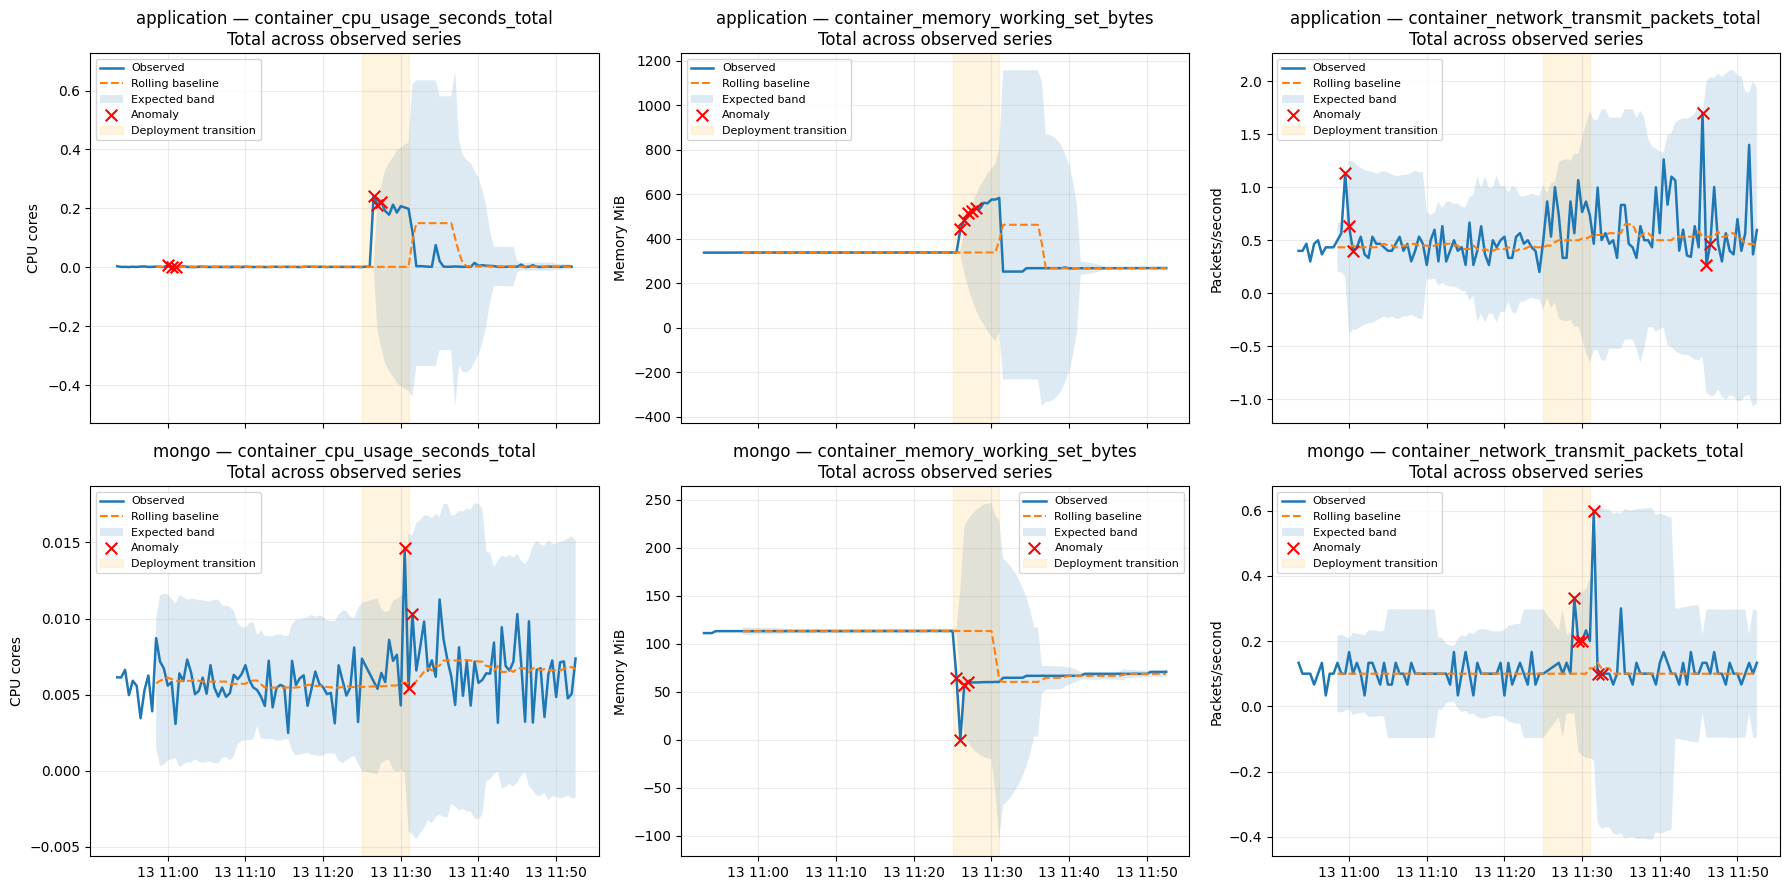

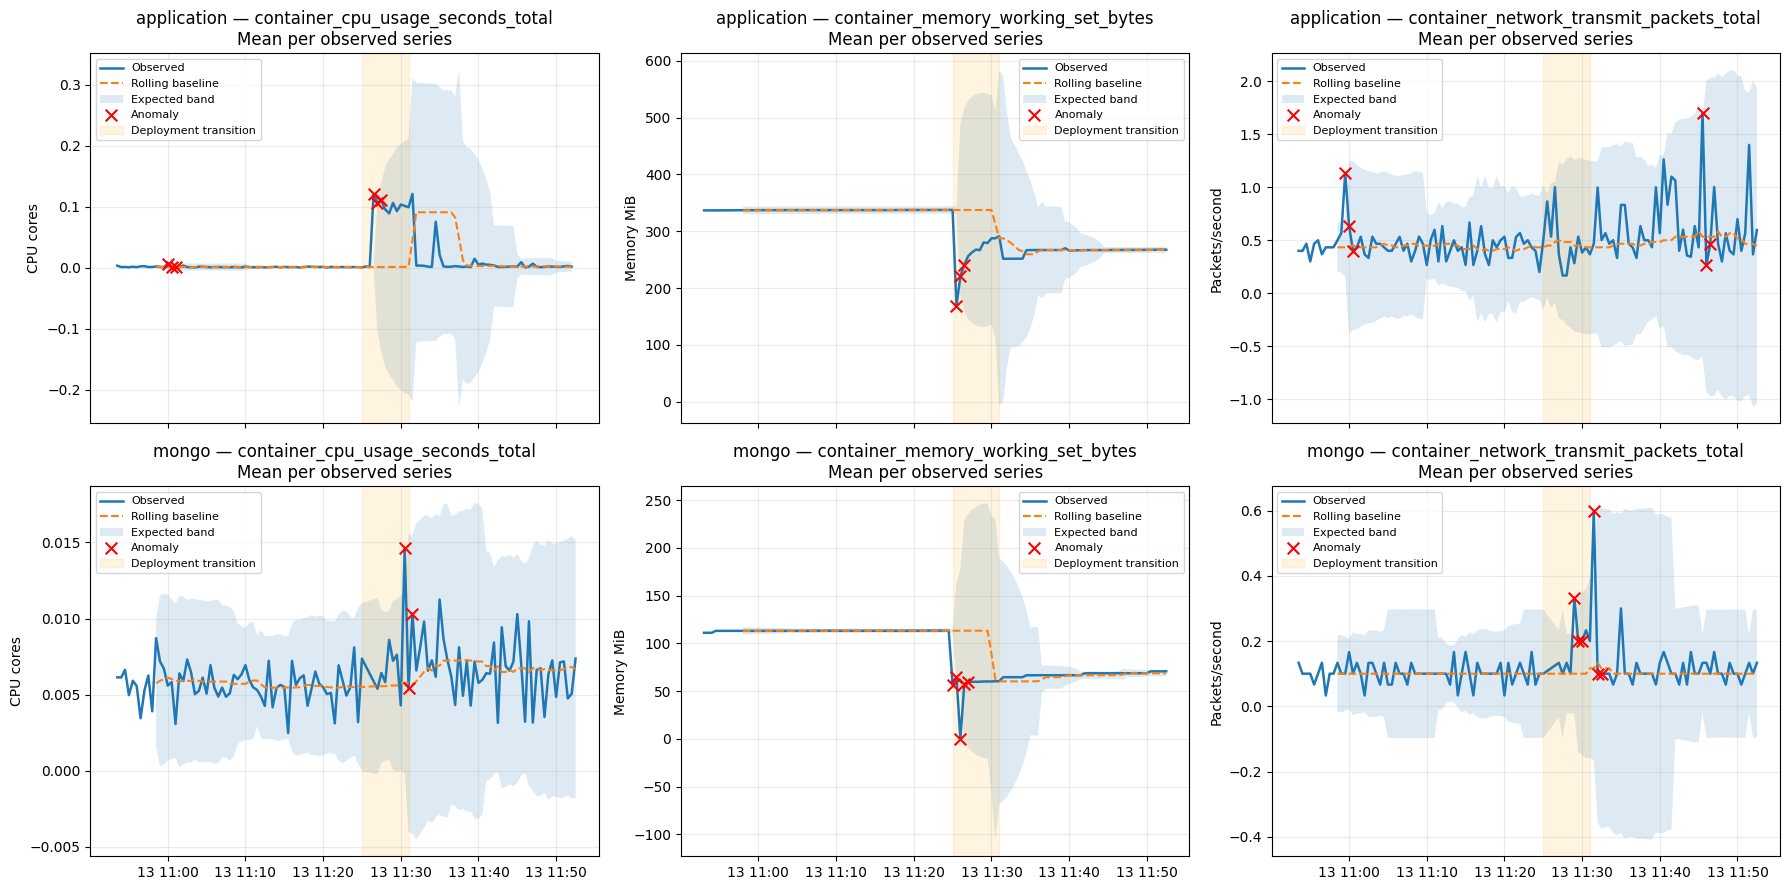

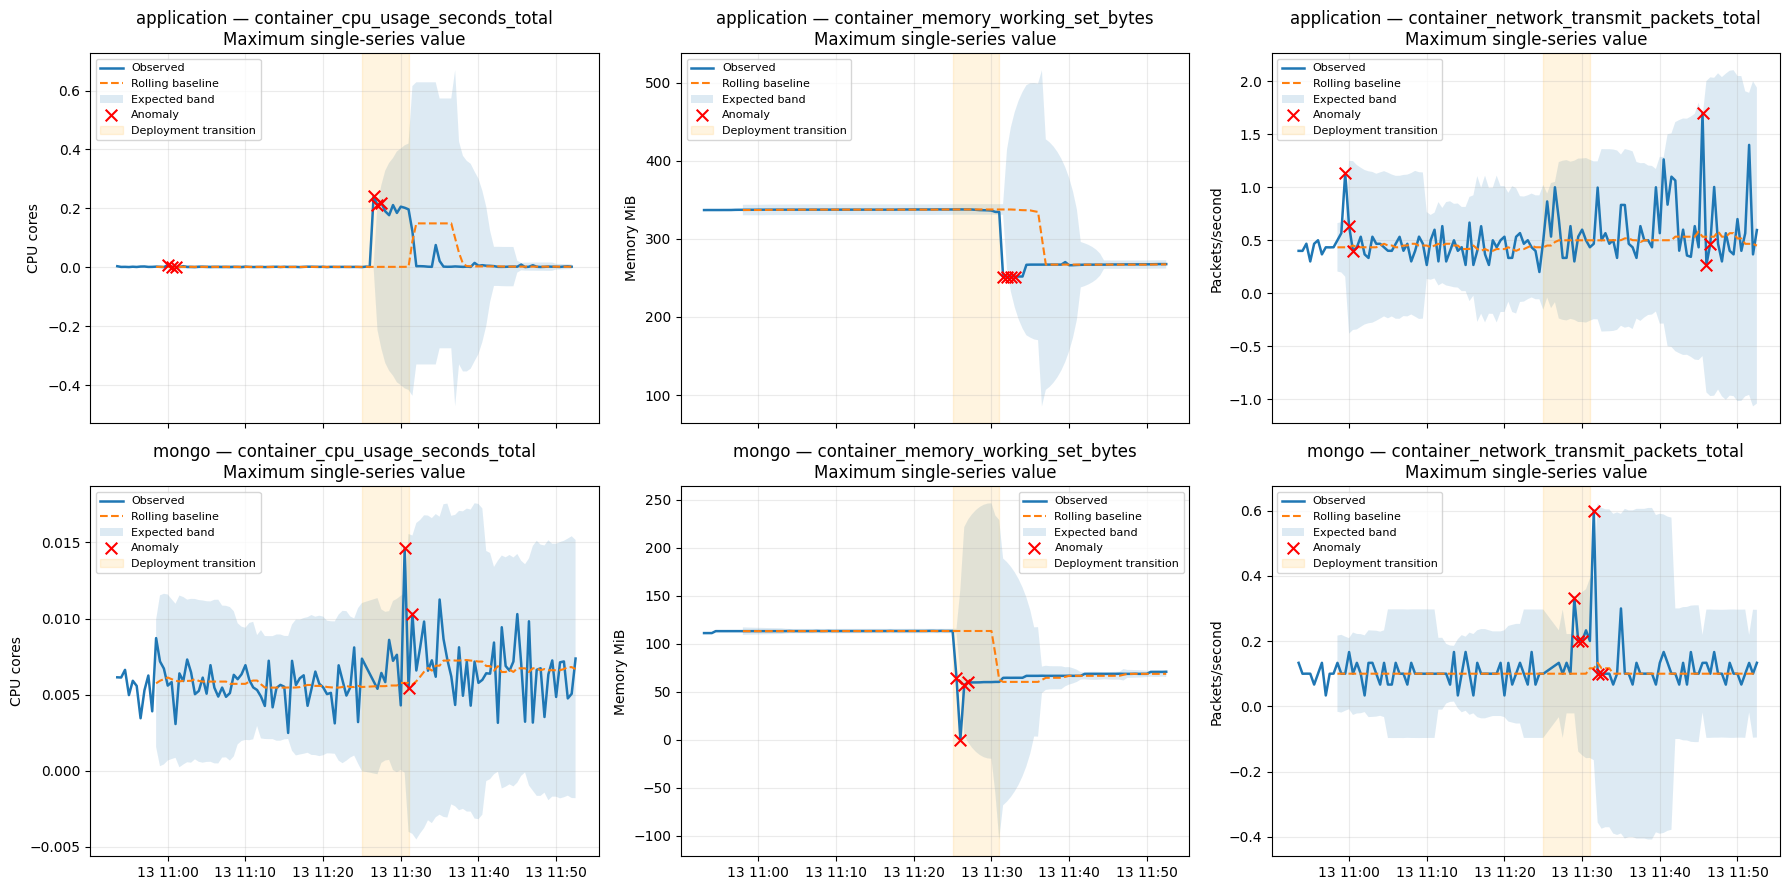

In [67]:
features_to_plot = {
    "value_sum": "Total across observed series",
    "value_mean": "Mean per observed series",
    "value_max": "Maximum single-series value",
}

for feature_name, feature_label in features_to_plot.items():
    plot_detected_feature(
        feature_name=feature_name,
        feature_label=feature_label,
    )

## 10. Correlate anomaly evidence into incidents

Convert detector-level anomaly points into progressively broader operational evidence: feature episodes, entity-metric events, entity-level incidents, and cross-entity scenario candidates.

### 10.1 Layer 1: Feature episodes

Merge consecutive anomaly points from the same entity, metric, feature, and direction into one feature-level episode. A gap of at most 90 seconds keeps points in the same episode.

In [68]:
CORRELATION_GAP = pd.Timedelta("90s")

STREAM_COLUMNS = [
    "entity",
    "metric_name",
    "feature_name",
]

# Count changes are contextual evidence. They do not change the MAD score.
detected_context = detected.sort_values(
    STREAM_COLUMNS + ["timestamp"]
).copy()

detected_context["active_pod_changed"] = (
    detected_context
    .groupby(STREAM_COLUMNS)["active_pod_count"]
    .transform(lambda values: values.diff().fillna(0).ne(0))
)

detected_context["observed_series_changed"] = (
    detected_context
    .groupby(STREAM_COLUMNS)["observed_series_count"]
    .transform(lambda values: values.diff().fillna(0).ne(0))
)

anomaly_points = detected_context[
    detected_context["is_anomaly"]
].copy()

feature_episode_rows = []
episode_counter = 0

episode_group_columns = STREAM_COLUMNS + ["direction"]

for keys, group in anomaly_points.groupby(
    episode_group_columns,
    sort=False,
):
    group = group.sort_values("timestamp").copy()

    # Start a new episode when the distance from the previous anomaly
    # is greater than the configured correlation gap.
    group["local_episode"] = (
        group["timestamp"]
        .diff()
        .gt(CORRELATION_GAP)
        .fillna(False)
        .cumsum()
    )

    entity, metric_name, feature_name, direction = keys

    for _, episode in group.groupby("local_episode", sort=False):
        episode_counter += 1

        feature_episode_rows.append({
            "feature_episode_id": f"feature_episode_{episode_counter:04d}",
            "entity": entity,
            "metric_name": metric_name,
            "feature_name": feature_name,
            "direction": direction,
            "start_time": episode["timestamp"].min(),
            "end_time": episode["timestamp"].max(),
            "duration_seconds": (
                episode["timestamp"].max()
                - episode["timestamp"].min()
            ).total_seconds(),
            "anomaly_points": len(episode),
            "max_abs_score": episode["anomaly_score"].abs().max(),
            "peak_observed_value": (
                episode.loc[
                    episode["anomaly_score"].abs().idxmax(),
                    "observed_value",
                ]
            ),
            "active_pod_count_min": episode["active_pod_count"].min(),
            "active_pod_count_max": episode["active_pod_count"].max(),
            "observed_series_count_min": episode["observed_series_count"].min(),
            "observed_series_count_max": episode["observed_series_count"].max(),
            "contributor_count_changed": bool(
                episode["active_pod_changed"].any()
                or episode["observed_series_changed"].any()
            ),
        })

feature_episodes = (
    pd.DataFrame(feature_episode_rows)
    .sort_values(["start_time", "entity", "metric_name", "feature_name"])
    .reset_index(drop=True)
)

display(feature_episodes)

,feature_episode_id,entity,metric_name,feature_name,direction,start_time,end_time,duration_seconds,anomaly_points,max_abs_score,peak_observed_value,active_pod_count_min,active_pod_count_max,observed_series_count_min,observed_series_count_max,contributor_count_changed
0,feature_episode_0013,application,container_network_transmit_packets_total,value_max,high,2022-07-13 10:59:30+00:00,2022-07-13 11:00:00+00:00,30.0,2,10.075789,1.133333,1,1,1,1,False
1,feature_episode_0017,application,container_network_transmit_packets_total,value_mean,high,2022-07-13 10:59:30+00:00,2022-07-13 11:00:00+00:00,30.0,2,10.075789,1.133333,1,1,1,1,False
2,feature_episode_0021,application,container_network_transmit_packets_total,value_sum,high,2022-07-13 10:59:30+00:00,2022-07-13 11:00:00+00:00,30.0,2,10.075789,1.133333,1,1,1,1,False
3,feature_episode_0001,application,container_cpu_usage_seconds_total,value_max,high,2022-07-13 11:00:00+00:00,2022-07-13 11:01:00+00:00,60.0,2,6.681599,0.006931,1,1,1,1,False
4,feature_episode_0004,application,container_cpu_usage_seconds_total,value_mean,high,2022-07-13 11:00:00+00:00,2022-07-13 11:01:00+00:00,60.0,2,6.681599,0.006931,1,1,1,1,False
5,feature_episode_0007,application,container_cpu_usage_seconds_total,value_sum,high,2022-07-13 11:00:00+00:00,2022-07-13 11:01:00+00:00,60.0,2,6.681599,0.006931,1,1,1,1,False
6,feature_episode_0003,application,container_cpu_usage_seconds_total,value_max,low,2022-07-13 11:00:30+00:00,2022-07-13 11:00:30+00:00,0.0,1,0.157031,0.001139,1,1,1,1,False
7,feature_episode_0006,application,container_cpu_usage_seconds_total,value_mean,low,2022-07-13 11:00:30+00:00,2022-07-13 11:00:30+00:00,0.0,1,0.157031,0.001139,1,1,1,1,False
8,feature_episode_0009,application,container_cpu_usage_seconds_total,value_sum,low,2022-07-13 11:00:30+00:00,2022-07-13 11:00:30+00:00,0.0,1,0.157031,0.001139,1,1,1,1,False
9,feature_episode_0015,application,container_network_transmit_packets_total,value_max,low,2022-07-13 11:00:30+00:00,2022-07-13 11:00:30+00:00,0.0,1,0.249377,0.400601,1,1,1,1,False


### 10.2 Layer 2: Entity-metric events

Merge overlapping or nearby sum, mean, and maximum episodes for the same entity and metric, including episodes with different directions. Directions are retained as feature-level signals so opposing movements can reveal load distribution or changes in the number of metric contributors.

In [69]:
def add_interval_cluster_ids(
    frame,
    group_columns,
    start_column="start_time",
    end_column="end_time",
    max_gap=CORRELATION_GAP,
):
    """Assign transitive time-overlap clusters within each group."""
    result = frame.copy()
    cluster_ids = pd.Series(index=result.index, dtype="Int64")
    next_cluster_id = 0

    grouped = (
        result.groupby(group_columns, sort=False, dropna=False)
        if group_columns
        else [(None, result)]
    )

    for _, group in grouped:
        group = group.sort_values([start_column, end_column])
        current_cluster_id = None
        current_end = None

        for index, row in group.iterrows():
            starts_new_cluster = (
                current_end is None
                or row[start_column] > current_end + max_gap
            )

            if starts_new_cluster:
                next_cluster_id += 1
                current_cluster_id = next_cluster_id
                current_end = row[end_column]
            else:
                current_end = max(current_end, row[end_column])

            cluster_ids.loc[index] = current_cluster_id

    result["cluster_id"] = cluster_ids.astype(int)
    return result


def interpret_feature_pattern(
    feature_signals,
    contributor_count_changed,
    single_contributor,
):
    signals = set(feature_signals)

    sum_high = "value_sum:high" in signals
    sum_low = "value_sum:low" in signals
    mean_high = "value_mean:high" in signals
    mean_low = "value_mean:low" in signals
    max_high = "value_max:high" in signals
    max_low = "value_max:low" in signals

    if single_contributor and len(signals) > 1:
        return "single_contributor_duplicate_views"

    if sum_high and mean_low:
        return "possible_composition_change"

    if sum_high and mean_high and max_high:
        return "broad_load_increase"

    if sum_high and mean_high:
        return "distributed_load_increase"

    if sum_high and max_high and not mean_high and not mean_low and contributor_count_changed:
        return "possible_scale_or_rollout_with_hot_contributor"

    if sum_high and not mean_high and not mean_low and contributor_count_changed:
        return "possible_scale_or_rollout"

    if max_high and not mean_high and not mean_low:
        return "possible_isolated_series_spike"

    if sum_low and (mean_high or max_high):
        return "possible_reduced_capacity_with_higher_per_series_load"

    if sum_low and contributor_count_changed:
        return "possible_lifecycle_or_telemetry_drop"

    if sum_low and mean_low and max_low:
        return "broad_load_decrease"

    if mean_high and max_high and not sum_high:
        return "possible_per_series_pressure_increase"

    if len(signals) > 1:
        return "mixed_multi_feature_change"

    return "single_feature_change"


episodes_clustered = add_interval_cluster_ids(
    feature_episodes,
    group_columns=["entity", "metric_name"],
)

metric_event_rows = []

for _, event in episodes_clustered.groupby("cluster_id", sort=False):
    features = sorted(event["feature_name"].unique())
    feature_signals = sorted({
        f"{row.feature_name}:{row.direction}"
        for row in event.itertuples()
    })
    directions = sorted(event["direction"].unique())
    contributor_count_changed = bool(
        event["contributor_count_changed"].any()
    )
    single_contributor = bool(
        event["observed_series_count_max"].max() <= 1
    )

    metric_event_rows.append({
        "metric_event_id": f"metric_event_{int(event['cluster_id'].iloc[0]):04d}",
        "entity": event["entity"].iloc[0],
        "metric_name": event["metric_name"].iloc[0],
        "start_time": event["start_time"].min(),
        "end_time": event["end_time"].max(),
        "features": features,
        "feature_count": len(features),
        "feature_signals": feature_signals,
        "directions": directions,
        "feature_episode_count": len(event),
        "anomaly_points": event["anomaly_points"].sum(),
        "max_abs_score": event["max_abs_score"].max(),
        "active_pod_count_min": event["active_pod_count_min"].min(),
        "active_pod_count_max": event["active_pod_count_max"].max(),
        "observed_series_count_min": event["observed_series_count_min"].min(),
        "observed_series_count_max": event["observed_series_count_max"].max(),
        "single_contributor": single_contributor,
        "contributor_count_changed": contributor_count_changed,
        "pattern": interpret_feature_pattern(
            feature_signals,
            contributor_count_changed,
            single_contributor,
        ),
        "source_feature_episode_ids": sorted(
            event["feature_episode_id"].tolist()
        ),
    })

entity_metric_events = (
    pd.DataFrame(metric_event_rows)
    .sort_values(["start_time", "entity", "metric_name"])
    .reset_index(drop=True)
)

display(entity_metric_events)

,metric_event_id,entity,metric_name,start_time,end_time,features,feature_count,feature_signals,directions,feature_episode_count,anomaly_points,max_abs_score,active_pod_count_min,active_pod_count_max,observed_series_count_min,observed_series_count_max,single_contributor,contributor_count_changed,pattern,source_feature_episode_ids
0,metric_event_0001,application,container_network_transmit_packets_total,2022-07-13 10:59:30+00:00,2022-07-13 11:00:30+00:00,"[value_max, value_mean, value_sum]",3,"[value_max:high, value_max:low, value_mean:hig...","[high, low]",6,9,10.075789,1,1,1,1,True,False,single_contributor_duplicate_views,"[feature_episode_0013, feature_episode_0015, f..."
1,metric_event_0003,application,container_cpu_usage_seconds_total,2022-07-13 11:00:00+00:00,2022-07-13 11:01:00+00:00,"[value_max, value_mean, value_sum]",3,"[value_max:high, value_max:low, value_mean:hig...","[high, low]",6,9,6.681599,1,1,1,1,True,False,single_contributor_duplicate_views,"[feature_episode_0001, feature_episode_0003, f..."
2,metric_event_0005,mongo,container_memory_working_set_bytes,2022-07-13 11:25:00+00:00,2022-07-13 11:27:00+00:00,"[value_max, value_mean, value_sum]",3,"[value_max:low, value_mean:low, value_sum:low]",[low],3,13,99.974128,1,2,1,2,False,True,possible_lifecycle_or_telemetry_drop,"[feature_episode_0031, feature_episode_0032, f..."
3,metric_event_0006,application,container_memory_working_set_bytes,2022-07-13 11:25:30+00:00,2022-07-13 11:28:00+00:00,"[value_mean, value_sum]",2,"[value_mean:low, value_sum:high]","[high, low]",2,8,99.973386,2,2,2,2,False,True,possible_composition_change,"[feature_episode_0011, feature_episode_0012]"
4,metric_event_0004,application,container_cpu_usage_seconds_total,2022-07-13 11:26:30+00:00,2022-07-13 11:27:30+00:00,"[value_max, value_mean, value_sum]",3,"[value_max:high, value_mean:high, value_sum:high]",[high],3,9,578.222786,2,2,2,2,False,True,broad_load_increase,"[feature_episode_0002, feature_episode_0005, f..."
5,metric_event_0008,mongo,container_network_transmit_packets_total,2022-07-13 11:29:00+00:00,2022-07-13 11:32:30+00:00,"[value_max, value_mean, value_sum]",3,"[value_max:high, value_max:low, value_mean:hig...","[high, low]",6,18,7.658943,1,1,1,1,True,False,single_contributor_duplicate_views,"[feature_episode_0034, feature_episode_0035, f..."
6,metric_event_0009,mongo,container_cpu_usage_seconds_total,2022-07-13 11:30:30+00:00,2022-07-13 11:31:30+00:00,"[value_max, value_mean, value_sum]",3,"[value_max:high, value_max:low, value_mean:hig...","[high, low]",6,9,6.013590,1,1,1,1,True,False,single_contributor_duplicate_views,"[feature_episode_0025, feature_episode_0026, f..."
7,metric_event_0007,application,container_memory_working_set_bytes,2022-07-13 11:31:30+00:00,2022-07-13 11:33:00+00:00,[value_max],1,[value_max:low],[low],1,4,50.925712,1,1,1,1,True,True,single_feature_change,[feature_episode_0010]
8,metric_event_0002,application,container_network_transmit_packets_total,2022-07-13 11:45:30+00:00,2022-07-13 11:46:30+00:00,"[value_max, value_mean, value_sum]",3,"[value_max:high, value_max:low, value_mean:hig...","[high, low]",6,9,4.140594,1,1,1,1,True,False,single_contributor_duplicate_views,"[feature_episode_0014, feature_episode_0016, f..."


### 10.3 Layer 3: Entity-level incidents

Correlate nearby CPU, memory, and network events within the same entity. High and low directions may coexist in one incident because different resources can move in opposite directions during the same transition.

In [70]:
metric_events_clustered = add_interval_cluster_ids(
    entity_metric_events,
    group_columns=["entity"],
)

entity_incident_rows = []

for _, incident in metric_events_clustered.groupby("cluster_id", sort=False):
    affected_metrics = sorted(incident["metric_name"].unique())
    metric_signals = sorted({
        f"{row.metric_name}:{feature_signal}"
        for row in incident.itertuples()
        for feature_signal in row.feature_signals
    })

    if len(affected_metrics) >= 3:
        incident_type = "multi_metric_resource_transition"
    elif len(affected_metrics) == 2:
        incident_type = "correlated_resource_event"
    else:
        incident_type = "single_metric_event"

    entity_incident_rows.append({
        "entity_incident_id": f"entity_incident_{int(incident['cluster_id'].iloc[0]):04d}",
        "entity": incident["entity"].iloc[0],
        "start_time": incident["start_time"].min(),
        "end_time": incident["end_time"].max(),
        "affected_metrics": affected_metrics,
        "affected_metric_count": len(affected_metrics),
        "metric_signals": metric_signals,
        "metric_event_count": len(incident),
        "anomaly_points": incident["anomaly_points"].sum(),
        "max_abs_score": incident["max_abs_score"].max(),
        "contributor_count_changed": bool(
            incident["contributor_count_changed"].any()
        ),
        "incident_type": incident_type,
        "source_metric_event_ids": sorted(
            incident["metric_event_id"].tolist()
        ),
    })

entity_incidents = (
    pd.DataFrame(entity_incident_rows)
    .sort_values(["start_time", "entity"])
    .reset_index(drop=True)
)

display(entity_incidents)

,entity_incident_id,entity,start_time,end_time,affected_metrics,affected_metric_count,metric_signals,metric_event_count,anomaly_points,max_abs_score,contributor_count_changed,incident_type,source_metric_event_ids
0,entity_incident_0001,application,2022-07-13 10:59:30+00:00,2022-07-13 11:01:00+00:00,"[container_cpu_usage_seconds_total, container_...",2,[container_cpu_usage_seconds_total:value_max:h...,2,18,10.075789,False,correlated_resource_event,"[metric_event_0001, metric_event_0003]"
1,entity_incident_0005,mongo,2022-07-13 11:25:00+00:00,2022-07-13 11:27:00+00:00,[container_memory_working_set_bytes],1,[container_memory_working_set_bytes:value_max:...,1,13,99.974128,True,single_metric_event,[metric_event_0005]
2,entity_incident_0002,application,2022-07-13 11:25:30+00:00,2022-07-13 11:28:00+00:00,"[container_cpu_usage_seconds_total, container_...",2,[container_cpu_usage_seconds_total:value_max:h...,2,17,578.222786,True,correlated_resource_event,"[metric_event_0004, metric_event_0006]"
3,entity_incident_0006,mongo,2022-07-13 11:29:00+00:00,2022-07-13 11:32:30+00:00,"[container_cpu_usage_seconds_total, container_...",2,[container_cpu_usage_seconds_total:value_max:h...,2,27,7.658943,False,correlated_resource_event,"[metric_event_0008, metric_event_0009]"
4,entity_incident_0003,application,2022-07-13 11:31:30+00:00,2022-07-13 11:33:00+00:00,[container_memory_working_set_bytes],1,[container_memory_working_set_bytes:value_max:...,1,4,50.925712,True,single_metric_event,[metric_event_0007]
5,entity_incident_0004,application,2022-07-13 11:45:30+00:00,2022-07-13 11:46:30+00:00,[container_network_transmit_packets_total],1,[container_network_transmit_packets_total:valu...,1,9,4.140594,False,single_metric_event,[metric_event_0002]


### 10.4 Layer 4: Cross-entity incident candidates

Merge nearby application and MongoDB incidents into scenario-level candidates. A result with two affected entities is cross-entity evidence; a one-entity result remains a local incident candidate.

In [71]:
entity_incidents_clustered = add_interval_cluster_ids(
    entity_incidents,
    group_columns=[],
)

cross_entity_rows = []

for _, candidate in entity_incidents_clustered.groupby(
    "cluster_id",
    sort=False,
):
    affected_entities = sorted(candidate["entity"].unique())
    affected_metrics = sorted({
        metric_name
        for metric_names in candidate["affected_metrics"]
        for metric_name in metric_names
    })

    scope = (
        "cross_entity"
        if len(affected_entities) > 1
        else "entity_local"
    )

    cross_entity_rows.append({
        "scenario_incident_id": f"scenario_incident_{int(candidate['cluster_id'].iloc[0]):04d}",
        "scenario_id": SCENARIO_ID,
        "start_time": candidate["start_time"].min(),
        "end_time": candidate["end_time"].max(),
        "scope": scope,
        "affected_entities": affected_entities,
        "affected_entity_count": len(affected_entities),
        "affected_metrics": affected_metrics,
        "affected_metric_count": len(affected_metrics),
        "entity_incident_count": len(candidate),
        "anomaly_points": candidate["anomaly_points"].sum(),
        "max_abs_score": candidate["max_abs_score"].max(),
        "contributor_count_changed": bool(
            candidate["contributor_count_changed"].any()
        ),
        "source_entity_incident_ids": sorted(
            candidate["entity_incident_id"].tolist()
        ),
    })

cross_entity_incidents = (
    pd.DataFrame(cross_entity_rows)
    .sort_values("start_time")
    .reset_index(drop=True)
)

display(cross_entity_incidents)

# Strict cross-entity view when only application + MongoDB correlations are needed.
display(
    cross_entity_incidents[
        cross_entity_incidents["scope"].eq("cross_entity")
    ]
)

,scenario_incident_id,scenario_id,start_time,end_time,scope,affected_entities,affected_entity_count,affected_metrics,affected_metric_count,entity_incident_count,anomaly_points,max_abs_score,contributor_count_changed,source_entity_incident_ids
0,scenario_incident_0001,ts-auth-mongo_4.4.15_2022-07-13,2022-07-13 10:59:30+00:00,2022-07-13 11:01:00+00:00,entity_local,[application],1,"[container_cpu_usage_seconds_total, container_...",2,1,18,10.075789,False,[entity_incident_0001]
1,scenario_incident_0002,ts-auth-mongo_4.4.15_2022-07-13,2022-07-13 11:25:00+00:00,2022-07-13 11:33:00+00:00,cross_entity,"[application, mongo]",2,"[container_cpu_usage_seconds_total, container_...",3,4,61,578.222786,True,"[entity_incident_0002, entity_incident_0003, e..."
2,scenario_incident_0003,ts-auth-mongo_4.4.15_2022-07-13,2022-07-13 11:45:30+00:00,2022-07-13 11:46:30+00:00,entity_local,[application],1,[container_network_transmit_packets_total],1,1,9,4.140594,False,[entity_incident_0004]


,scenario_incident_id,scenario_id,start_time,end_time,scope,affected_entities,affected_entity_count,affected_metrics,affected_metric_count,entity_incident_count,anomaly_points,max_abs_score,contributor_count_changed,source_entity_incident_ids
1,scenario_incident_0002,ts-auth-mongo_4.4.15_2022-07-13,2022-07-13 11:25:00+00:00,2022-07-13 11:33:00+00:00,cross_entity,"[application, mongo]",2,"[container_cpu_usage_seconds_total, container_...",3,4,61,578.222786,True,"[entity_incident_0002, entity_incident_0003, e..."


## 11. Export metric incident candidates

Export scenario-level metric candidates with a shared time, service-identity, correlation, evidence, and provenance contract. The same core fields should be used later by `log_incident_candidates.json` so cross-signal correlation can join candidates by scenario, normalized UTC interval, and canonical service keys.

In [72]:
import hashlib


SCHEMA_NAME = "aiops.metric_incident_candidates"
SCHEMA_VERSION = "1.0.0"
CORRELATOR_VERSION = "1.0.0"

ENTITY_CATALOG = {
    "application": {
        "role": "application",
        "service": {
            "namespace": "train-ticket",
            "name": "ts-auth-service",
        },
    },
    "mongo": {
        "role": "database",
        "service": {
            "namespace": "train-ticket",
            "name": "ts-auth-mongo",
        },
    },
}


def to_rfc3339_utc(value):
    timestamp = pd.Timestamp(value)

    if timestamp.tzinfo is None:
        timestamp = timestamp.tz_localize("UTC")
    else:
        timestamp = timestamp.tz_convert("UTC")

    return timestamp.isoformat().replace("+00:00", "Z")


def finite_float(value):
    number = float(value)
    return number if np.isfinite(number) else None


def stable_candidate_id(identity):
    canonical = json.dumps(
        identity,
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
    )
    digest = hashlib.sha256(canonical.encode("utf-8")).hexdigest()
    return f"mic_{digest[:16]}"


def service_key(entity_record):
    service = entity_record["service"]
    return f"{service['namespace']}/{service['name']}"


generated_at = pd.Timestamp.now(tz="UTC")
metric_event_lookup = entity_metric_events.set_index("metric_event_id")
entity_incident_lookup = entity_incidents.set_index("entity_incident_id")

candidate_records = []

for candidate in cross_entity_incidents.itertuples(index=False):
    entity_records = [
        ENTITY_CATALOG[entity_name]
        for entity_name in candidate.affected_entities
    ]
    entity_records = sorted(
        entity_records,
        key=service_key,
    )
    service_keys = [service_key(record) for record in entity_records]

    start_time = pd.Timestamp(candidate.start_time)
    end_time = pd.Timestamp(candidate.end_time)

    evidence_records = []

    for entity_incident_id in candidate.source_entity_incident_ids:
        entity_incident = entity_incident_lookup.loc[entity_incident_id]
        entity_name = entity_incident["entity"]
        entity_catalog_record = ENTITY_CATALOG[entity_name]
        metric_evidence = []

        for metric_event_id in entity_incident["source_metric_event_ids"]:
            metric_event = metric_event_lookup.loc[metric_event_id]
            feature_signals = []

            for signal in metric_event["feature_signals"]:
                feature_name, direction = signal.split(":", maxsplit=1)
                feature_signals.append({
                    "feature": feature_name,
                    "direction": direction,
                })

            metric_evidence.append({
                "metric_name": metric_event["metric_name"],
                "event_time": {
                    "start": to_rfc3339_utc(metric_event["start_time"]),
                    "end": to_rfc3339_utc(metric_event["end_time"]),
                },
                "feature_signals": feature_signals,
                "pattern": metric_event["pattern"],
                "anomaly_point_count": int(metric_event["anomaly_points"]),
                "max_abs_score": finite_float(metric_event["max_abs_score"]),
                "single_contributor": bool(metric_event["single_contributor"]),
                "contributor_count_changed": bool(
                    metric_event["contributor_count_changed"]
                ),
            })

        evidence_records.append({
            "entity_role": entity_catalog_record["role"],
            "service": entity_catalog_record["service"],
            "event_time": {
                "start": to_rfc3339_utc(entity_incident["start_time"]),
                "end": to_rfc3339_utc(entity_incident["end_time"]),
            },
            "incident_type": entity_incident["incident_type"],
            "metric_evidence": metric_evidence,
        })

    identity = {
        "schema_version": SCHEMA_VERSION,
        "signal_source": "metrics",
        "scenario_id": SCENARIO_ID,
        "start": to_rfc3339_utc(start_time),
        "end": to_rfc3339_utc(end_time),
        "scope": candidate.scope,
        "service_keys": service_keys,
        "affected_metrics": sorted(candidate.affected_metrics),
    }

    candidate_records.append({
        "candidate_id": stable_candidate_id(identity),
        "signal_source": "metrics",
        "event_time": {
            "start": to_rfc3339_utc(start_time),
            "end": to_rfc3339_utc(end_time),
            "duration_seconds": float(
                (end_time - start_time).total_seconds()
            ),
        },
        "scope": {
            "level": candidate.scope,
            "entities": entity_records,
        },
        "correlation": {
            "scenario_id": SCENARIO_ID,
            "service_keys": service_keys,
            "time_tolerance_seconds": int(
                CORRELATION_GAP.total_seconds()
            ),
        },
        "summary": {
            "affected_metrics": sorted(candidate.affected_metrics),
            "anomaly_point_count": int(candidate.anomaly_points),
            "max_abs_score": finite_float(candidate.max_abs_score),
            "contributor_count_changed": bool(
                candidate.contributor_count_changed
            ),
        },
        "evidence": evidence_records,
    })

metric_incident_document = {
    "schema_name": SCHEMA_NAME,
    "schema_version": SCHEMA_VERSION,
    "generated_at": to_rfc3339_utc(generated_at),
    "producer": {
        "name": "02_metrics_detection",
        "pipeline_stage": "metric_detection_and_correlation",
        "detector": "rolling_median_mad",
        "correlator_version": CORRELATOR_VERSION,
    },
    "time_contract": {
        "normalized_timezone": "UTC",
        "timestamp_format": "RFC3339",
        "interval_semantics": "closed",
        "native_resolution_seconds": int(
            pd.Timedelta(RESAMPLE_INTERVAL).total_seconds()
        ),
        "default_correlation_tolerance_seconds": int(
            CORRELATION_GAP.total_seconds()
        ),
    },
    "provenance": {
        "notebook": "notebooks/02_metrics_detection.ipynb",
        "timestamp_normalization": {
            "source_timezone": "UTC",
            "applied_offset_seconds": 0,
            "assumption": False,
        },
    },
    "candidates": candidate_records,
}

OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
METRIC_INCIDENTS_PATH = OUTPUT_DIR / "metric_incident_candidates.json"

METRIC_INCIDENTS_PATH.write_text(
    json.dumps(
        metric_incident_document,
        ensure_ascii=False,
        indent=2,
        allow_nan=False,
    ),
    encoding="utf-8",
)

print("Exported:", METRIC_INCIDENTS_PATH.resolve())
print("Candidates:", len(candidate_records))
display(pd.DataFrame([
    {
        "candidate_id": record["candidate_id"],
        "start": record["event_time"]["start"],
        "end": record["event_time"]["end"],
        "scope": record["scope"]["level"],
        "services": record["correlation"]["service_keys"],
        "metrics": record["summary"]["affected_metrics"],
    }
    for record in candidate_records
]))

Exported: E:\AIO\Project\aiops-trainticket-pipeline\data\outputs\metric_incident_candidates.json
Candidates: 3


,candidate_id,start,end,scope,services,metrics
0,mic_85a3984a16912dc8,2022-07-13T10:59:30Z,2022-07-13T11:01:00Z,entity_local,[train-ticket/ts-auth-service],"[container_cpu_usage_seconds_total, container_..."
1,mic_b541dfeaa3ebbeea,2022-07-13T11:25:00Z,2022-07-13T11:33:00Z,cross_entity,"[train-ticket/ts-auth-mongo, train-ticket/ts-a...","[container_cpu_usage_seconds_total, container_..."
2,mic_51b6b1e4ab7d6e0d,2022-07-13T11:45:30Z,2022-07-13T11:46:30Z,entity_local,[train-ticket/ts-auth-service],[container_network_transmit_packets_total]
